In [59]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import models, transforms
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from starterskit import features, helpers
import cv2

In [60]:
dataset_path = '/Users/user/PycharmProjects/animalclassification'
output_path = './'

In [61]:
dataset_path_train = os.path.join(dataset_path, 'train')
dataset_path_test = os.path.join(dataset_path, 'test')
prediction_path = os.path.join(output_path, 'predictions')

In [62]:
folder_paths = glob.glob(os.path.join(dataset_path_train, '*'))
label_strings = np.sort(np.array([os.path.basename(path) for path in folder_paths]))

In [63]:
train_paths = {label: helpers.getImgPaths(os.path.join(dataset_path_train, label)) for label in label_strings}
test_paths = helpers.getImgPaths(dataset_path_test)

# Data Preprocessing and Feature Extraction


In [64]:
# Load pre-trained ResNet50 model
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Remove classification layer
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to the input size of ResNet
    transforms.ToTensor(),          # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Function to extract features using the pre-trained model
def extract_cnn_features(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0)  # Add batch dimension
    with torch.no_grad():
        features = model(img_tensor)  # Extract features
    return features.squeeze().numpy()

In [65]:
train_features, train_labels = [], []

for label_idx, (label, paths) in enumerate(train_paths.items()):
    print(f"Extracting features for label: {label}")
    for img_path in paths:
        train_features.append(extract_cnn_features(img_path))
        train_labels.append(label_idx)

# Convert training features and labels to arrays
X_train = np.array(train_features)
y_train = np.array(train_labels)

# Extract features for test set
test_features = [extract_cnn_features(img_path) for img_path in test_paths]
X_test = np.array(test_features)

Extracting features for label: chicken
Extracting features for label: elephant
Extracting features for label: fox
Extracting features for label: german_shepherd
Extracting features for label: golden_retriever
Extracting features for label: horse
Extracting features for label: jaguar
Extracting features for label: lion
Extracting features for label: owl


KeyboardInterrupt: 

In [91]:
# Split training data for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

In [92]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_split_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

In [93]:
# Simple logistic regression model
logreg = LogisticRegression(
    max_iter=2000, 
    random_state=42, 
    C=0.0001, # strong regularization to prevent overfitting
    class_weight='balanced' # to address class imbalance
)
logreg.fit(X_train_split_scaled, y_train_split)

# Evaluate on validation set
y_val_pred = logreg.predict(X_val)

In [94]:
# Print classification report
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=label_strings))

Validation Classification Report:
                  precision    recall  f1-score   support

         chicken       0.82      1.00      0.90       138
        elephant       0.98      0.99      0.99       109
             fox       0.98      1.00      0.99        62
 german_shepherd       0.93      0.99      0.96       116
golden_retriever       1.00      0.42      0.59        19
           horse       1.00      1.00      1.00       117
          jaguar       1.00      1.00      1.00        22
            lion       0.99      1.00      0.99        98
             owl       0.98      0.81      0.89        80
          parrot       0.96      0.97      0.97       101
            swan       1.00      0.74      0.85        53
           tiger       1.00      0.98      0.99        96

        accuracy                           0.95      1011
       macro avg       0.97      0.91      0.93      1011
    weighted avg       0.96      0.95      0.95      1011



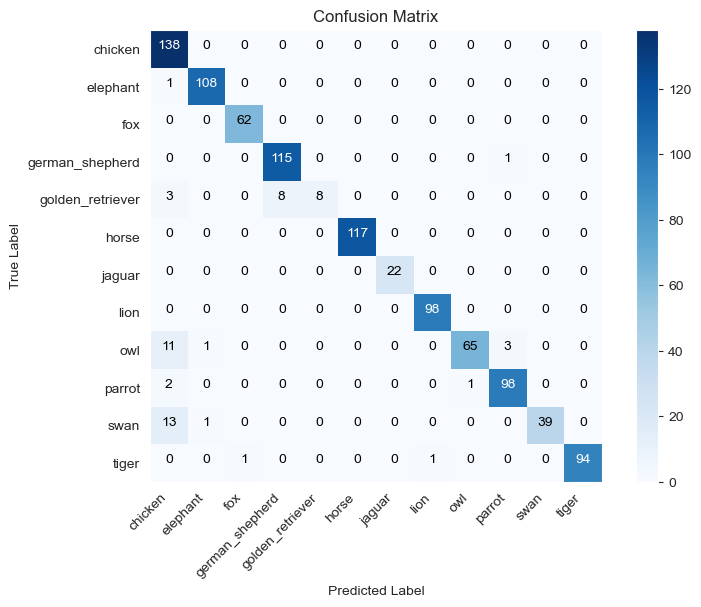

In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(label_strings))
plt.xticks(tick_marks, label_strings, rotation=45, ha='right')
plt.yticks(tick_marks, label_strings)

# Annotate the confusion matrix
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.grid(False)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [96]:
y_test_proba = logreg.predict_proba(X_test)

pred_file_path = os.path.join(prediction_path, helpers.generateUniqueFilename('cnn', 'csv'))
helpers.writePredictionsToCsv(y_test_proba, pred_file_path, label_strings)

print(f"Submission file saved to: {pred_file_path}")

Submission file saved to: ./predictions/cnn_20250115-231131.csv
